# **Graph Metrics (*Number of Edges*)**

## 📦 **Package Import**

In [1]:
# python
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import sys
import os
from pathlib import Path

# algorithms4pepprotgraphs framework
sys.path.append('/home/jovyan/work/PepProtGraphAnalyzer')
from PepProtGraphAnalyzer.module.notebook import NotebookApp
from PepProtGraphAnalyzer.util.plotting import boxplot, scatter

app = NotebookApp('.env.jupyter.AVPExternal')
paths = app.paths()

[2025-09-23 19:38:11,719] WARNING [data_validator.py:87] Sequences with non-natural amino acids were excluded. See: /home/jovyan/work/output/out_paper/AVP-external/Log/Sequences with Non-Natural Amino Acids.csv
[2025-09-23 19:38:28,447] INFO [notebook.py:70] Setting:
dataset_path: /home/jovyan/work/PepProtGraphAnalyzer/dataset/AVPDiscover/AVP-external.csv
pdb_path: /home/jovyan/work/PepProtGraphAnalyzer/dataset/AVPDiscover/ESMFold_pdbs
notebook_output_path: /home/jovyan/work/output/out_paper/AVP-external
sequence_analysis_path: /home/jovyan/work/PepProtGraphAnalyzer/output/results_with_seq_10_to_100/AVPExternal/2025-04-07T19.52.26-Sequence_Analyzer
graph_analysis_path: /home/jovyan/work/PepProtGraphAnalyzer/output/results_with_seq_10_to_100/AVPExternal/2025-04-07T21.26.46-Graph_Analyzer
min_seq_len: 10
max_seq_len: 100


## 📊 **Data Analysis**

### **Data**

In [2]:
# data
data = pd.read_csv(app.graph_analysis['graph_metrics'])
data["distance_interval"] = data["distance_function"] + " " + data["interval"].astype(str)
data = data[["sequence", "distance_interval", "number_of_edges", "distance_function", "interval"]]

# statistics
statistics = pd.read_csv(
    app.graph_analysis['graph_metrics_summary'].with_name(
        app.graph_analysis['graph_metrics_summary'].name + "-number_of_connected_components.csv"
    )
)
statistics["distance_interval"] = statistics["distance_function"] + " " + statistics["interval"].astype(str)

data[["sequence", "distance_interval", "number_of_edges"]].head()

,sequence,distance_interval,number_of_edges
0,GWFDVVKHIASAV,"euclidean (0, 10.2836)",56
1,FLPLIGKVLSGIL,"euclidean (0, 10.2836)",41
2,FLSLIPHAINAVSTLVHHSG,"euclidean (0, 10.2836)",96
3,GVPCGESCVFIPCITGVIGCSCSSNVCYLN,"euclidean (0, 10.2836)",226
4,GLLSSLSSVAKHVLPHVVPVIAEHL,"euclidean (0, 10.2836)",122


### **Distance Intervals**

In [3]:
display(Markdown("\n".join(f"- {val}" for val in statistics["distance_interval"].unique())))

- angular_separation (0, 0.018)
- angular_separation (0, 0.0654)
- angular_separation (0, 0.1799)
- bhattacharyya (0, 1.5158)
- bhattacharyya (0, 2.4304)
- bhattacharyya (0, 3.6452)
- canberra (0, 0.6155)
- canberra (0, 1.0142)
- canberra (0, 1.4712)
- clark (0, 0.4161)
- clark (0, 0.6813)
- clark (0, 0.983)
- euclidean (0, 10.2836)
- euclidean (0, 16.6132)
- euclidean (0, 26.242)
- lance_williams (0, 0.1789)
- lance_williams (0, 0.3041)
- lance_williams (0, 0.466)
- soergel (0, 0.3035)
- soergel (0, 0.4664)
- soergel (0, 0.6357)

### **Analysis of Graph Number of Edges Distribution (*all distance intervals*)**

<br>Statistics (*All Distance Intervals*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"angular_separation (0, 0.018)",19754,1.0,4.441328,1.995217,3.0,4.0,6.0,14.0,0.414644,3.433524
1,"angular_separation (0, 0.0654)",19754,1.0,2.082566,1.066140,1.0,2.0,3.0,6.0,0.504602,2.071481
2,"angular_separation (0, 0.1799)",19754,1.0,1.370558,0.526209,1.0,1.0,2.0,4.0,0.984197,2.871635
3,"bhattacharyya (0, 1.5158)",19754,1.0,2.461071,0.901872,2.0,2.0,3.0,6.0,0.096226,2.398065
4,"bhattacharyya (0, 2.4304)",19754,1.0,1.077149,0.266834,1.0,1.0,1.0,2.0,3.169470,11.045541
5,"bhattacharyya (0, 3.6452)",19754,1.0,1.000000,0.000000,1.0,1.0,1.0,1.0,NaN,NaN
6,"canberra (0, 0.6155)",19754,3.0,6.485168,1.897758,5.0,6.0,8.0,17.0,0.725533,3.534663
7,"canberra (0, 1.0142)",19754,2.0,4.052648,0.894734,3.0,4.0,5.0,9.0,0.613044,4.193050
8,"canberra (0, 1.4712)",19754,1.0,1.760605,0.732649,1.0,2.0,2.0,5.0,0.522251,2.417288
9,"clark (0, 0.4161)",19754,3.0,6.664271,1.940118,5.0,6.0,8.0,16.0,0.693321,3.446647


<br>Graph Number of Edges (*All Distance Intervals*)

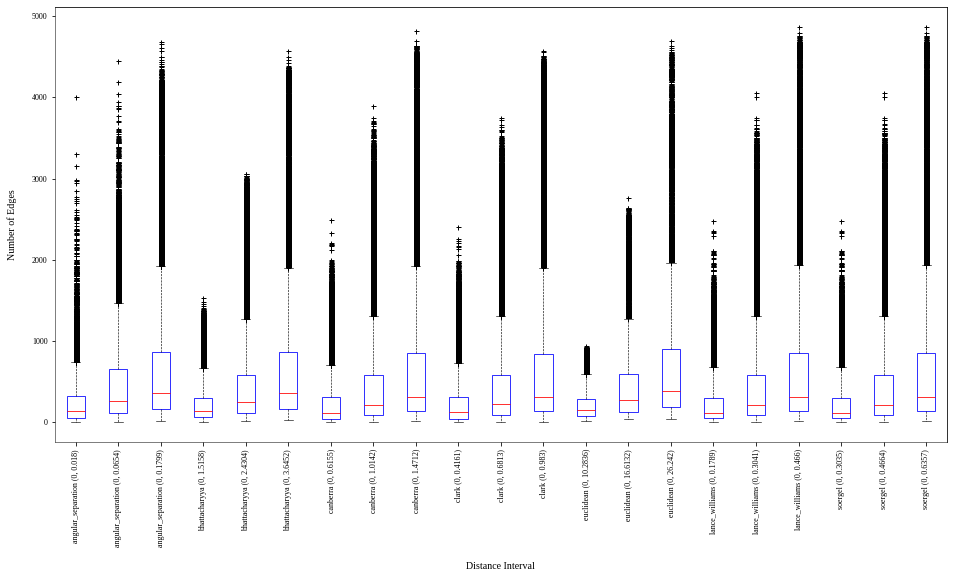

In [4]:
# statistics
display(Markdown("<br>Statistics (*All Distance Intervals*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics.reset_index(drop=True)[columns])

x_axis = 'distance_interval'
y_axis = 'number_of_edges'
x_label = 'Distance Interval'
y_label = 'Number of Edges'
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (all_distance_intervals) -histogram")

fig_size=(16, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>Graph Number of Edges (*All Distance Intervals*)"))
plt = boxplot(data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

### **Analysis of Graph Number of Edges Distribution (*per Distance Percentile*)**

#### **25th percentile distance intervals**

<br>Statistics (*25th percentile distance intervals*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"angular_separation (0, 0.018)",19754,1.0,4.441328,1.995217,3.0,4.0,6.0,14.0,0.414644,3.433524
1,"bhattacharyya (0, 1.5158)",19754,1.0,2.461071,0.901872,2.0,2.0,3.0,6.0,0.096226,2.398065
2,"canberra (0, 0.6155)",19754,3.0,6.485168,1.897758,5.0,6.0,8.0,17.0,0.725533,3.534663
3,"clark (0, 0.4161)",19754,3.0,6.664271,1.940118,5.0,6.0,8.0,16.0,0.693321,3.446647
4,"euclidean (0, 10.2836)",19754,1.0,1.000000,0.000000,1.0,1.0,1.0,1.0,NaN,NaN
5,"lance_williams (0, 0.1789)",19754,1.0,4.489521,2.238210,3.0,5.0,6.0,12.0,-0.199679,2.075342
6,"soergel (0, 0.3035)",19754,1.0,4.489673,2.238369,3.0,5.0,6.0,12.0,-0.199550,2.075415


<br>Graph Number of Edges (*25th percentile distance intervals*)

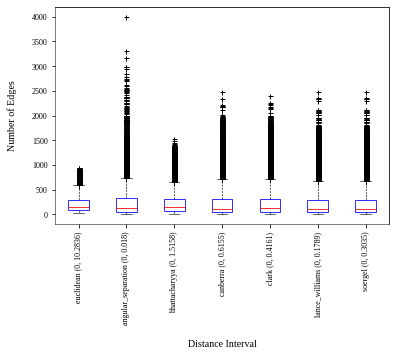

In [5]:
distance_intervals = [
    'euclidean (0, 10.2836)',
    'angular_separation (0, 0.018)',
    'bhattacharyya (0, 1.5158)',
    'canberra (0, 0.6155)',
    'clark (0, 0.4161)',
    'lance_williams (0, 0.1789)',
    'soergel (0, 0.3035)'  
]

current_data = data[data['distance_interval'].isin(distance_intervals)].copy()  

# statistics
display(Markdown("<br>Statistics (*25th percentile distance intervals*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_interval'].isin(distance_intervals)].reset_index(drop=True)[columns])

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
# x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance Interval'
y_label = 'Number of Edges'
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (p25_distance_intervals) -histogram")
fig_size=(6, 4)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>Graph Number of Edges (*25th percentile distance intervals*)"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, categories=distance_intervals, x_tick_rotation=x_tick_rotation)
plt.show()

#### **50th percentile distance intervals**

<br>Statistics (*50th percentile distance intervals*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"angular_separation (0, 0.0654)",19754,1.0,2.082566,1.066140,1.0,2.0,3.0,6.0,0.504602,2.071481
1,"bhattacharyya (0, 2.4304)",19754,1.0,1.077149,0.266834,1.0,1.0,1.0,2.0,3.169470,11.045541
2,"canberra (0, 1.0142)",19754,2.0,4.052648,0.894734,3.0,4.0,5.0,9.0,0.613044,4.193050
3,"clark (0, 0.6813)",19754,2.0,4.346461,1.018704,4.0,4.0,5.0,10.0,0.565391,3.714985
4,"euclidean (0, 16.6132)",19754,1.0,1.000000,0.000000,1.0,1.0,1.0,1.0,NaN,NaN
5,"lance_williams (0, 0.3041)",19754,1.0,2.221626,1.177630,1.0,2.0,3.0,6.0,0.322376,1.806147


<br>Graph Number of Edges (*50th percentile distance intervals*)

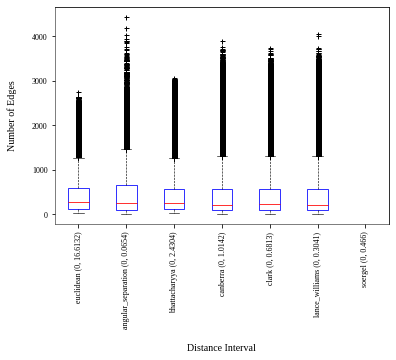

In [6]:
distance_intervals = [
    'euclidean (0, 16.6132)',
    'angular_separation (0, 0.0654)',
    'bhattacharyya (0, 2.4304)',
    'canberra (0, 1.0142)',
    'clark (0, 0.6813)',
    'lance_williams (0, 0.3041)',
    'soergel (0, 0.466)'  
]

# statistics
display(Markdown("<br>Statistics (*50th percentile distance intervals*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_interval'].isin(distance_intervals)].reset_index(drop=True)[columns])

current_data = data[data['distance_interval'].isin(distance_intervals)].copy()  

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
# x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance Interval'
y_label = 'Number of Edges'
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (p50_distance_intervals) -histogram")
fig_size=(6, 4)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>Graph Number of Edges (*50th percentile distance intervals*)"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, categories=distance_intervals, x_tick_rotation=x_tick_rotation)
plt.show()

#### **75th percentile distance intervals**

<br>Statistics (*75th percentile distance intervals*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"angular_separation (0, 0.1799)",19754,1.0,1.370558,0.526209,1.0,1.0,2.0,4.0,0.984197,2.871635
1,"bhattacharyya (0, 3.6452)",19754,1.0,1.000000,0.000000,1.0,1.0,1.0,1.0,NaN,NaN
2,"canberra (0, 1.4712)",19754,1.0,1.760605,0.732649,1.0,2.0,2.0,5.0,0.522251,2.417288
3,"clark (0, 0.983)",19754,2.0,3.639263,0.656731,3.0,4.0,4.0,7.0,-0.506704,3.432872
4,"euclidean (0, 26.242)",19754,1.0,1.000000,0.000000,1.0,1.0,1.0,1.0,NaN,NaN
5,"lance_williams (0, 0.466)",19754,1.0,1.450997,0.570147,1.0,1.0,2.0,4.0,0.820920,2.673500
6,"soergel (0, 0.6357)",19754,1.0,1.451048,0.570240,1.0,1.0,2.0,4.0,0.821221,2.674175


<br>Graph Number of Edges (*75th percentile distance intervals*)

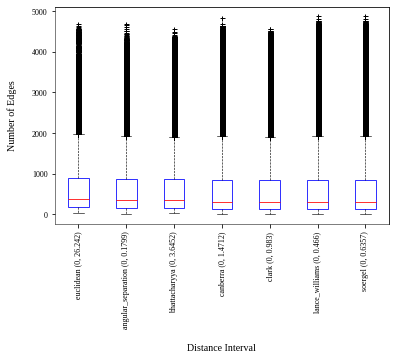

In [7]:
distance_intervals = [
    'euclidean (0, 26.242)',
    'angular_separation (0, 0.1799)',
    'bhattacharyya (0, 3.6452)',
    'canberra (0, 1.4712)',
    'clark (0, 0.983)',
    'lance_williams (0, 0.466)',
    'soergel (0, 0.6357)'  
]

# statistics
display(Markdown("<br>Statistics (*75th percentile distance intervals*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_interval'].isin(distance_intervals)].reset_index(drop=True)[columns])

current_data = data[data['distance_interval'].isin(distance_intervals)].copy()  

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
# x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance Interval'
y_label = 'Number of Edges'
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (p75_distance_intervals) -histogram")
fig_size=(6, 4)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>Graph Number of Edges (*75th percentile distance intervals*)"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, categories=distance_intervals, x_tick_rotation=x_tick_rotation)
plt.show()

### **Analysis of Graph Number of Edges Distribution (*per Distance Function*)**

#### **Euclidean**

<br>Statistics (*Euclidean*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"euclidean (0, 10.2836)",19754,1.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN,NaN
1,"euclidean (0, 16.6132)",19754,1.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN,NaN
2,"euclidean (0, 26.242)",19754,1.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN,NaN


<br>*Graph Number of Edges (*Euclidean*)*

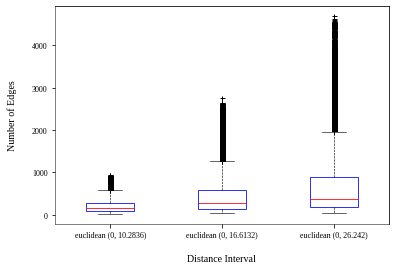

In [8]:
distance_function = 'euclidean'

# statistics
display(Markdown("<br>Statistics (*Euclidean*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
x_label = 'Distance Interval'
y_label = 'Number of Edges'
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (eu) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Number of Edges (*Euclidean*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Bhattacharyya**

<br>Statistics (*Bhattacharyya*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"bhattacharyya (0, 1.5158)",19754,1.0,2.461071,0.901872,2.0,2.0,3.0,6.0,0.096226,2.398065
1,"bhattacharyya (0, 2.4304)",19754,1.0,1.077149,0.266834,1.0,1.0,1.0,2.0,3.169470,11.045541
2,"bhattacharyya (0, 3.6452)",19754,1.0,1.000000,0.000000,1.0,1.0,1.0,1.0,NaN,NaN


<br>*Graph Number of Edges (*Bhattacharyya*)*

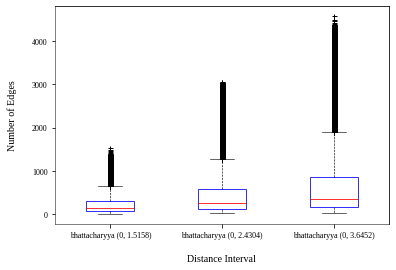

In [9]:
distance_function = 'bhattacharyya'

# statistics
display(Markdown("<br>Statistics (*Bhattacharyya*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
x_label = 'Distance Interval'
y_label = 'Number of Edges'
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (ba) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Number of Edges (*Bhattacharyya*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Canberra**

<br>Statistics (*Canberra*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"canberra (0, 0.6155)",19754,3.0,6.485168,1.897758,5.0,6.0,8.0,17.0,0.725533,3.534663
1,"canberra (0, 1.0142)",19754,2.0,4.052648,0.894734,3.0,4.0,5.0,9.0,0.613044,4.193050
2,"canberra (0, 1.4712)",19754,1.0,1.760605,0.732649,1.0,2.0,2.0,5.0,0.522251,2.417288


<br>*Graph Number of Edges (*Canberra*)*

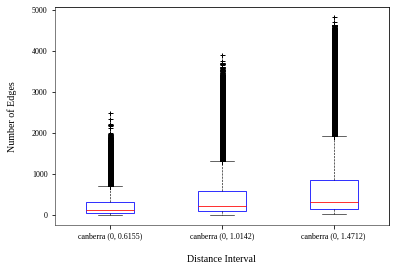

In [10]:
distance_function = 'canberra'

# statistics
display(Markdown("<br>Statistics (*Canberra*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
x_label = 'Distance Interval'
y_label = 'Number of Edges'
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (ca) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Number of Edges (*Canberra*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Clark**

<br>Statistics (*Clark*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"clark (0, 0.4161)",19754,3.0,6.664271,1.940118,5.0,6.0,8.0,16.0,0.693321,3.446647
1,"clark (0, 0.6813)",19754,2.0,4.346461,1.018704,4.0,4.0,5.0,10.0,0.565391,3.714985
2,"clark (0, 0.983)",19754,2.0,3.639263,0.656731,3.0,4.0,4.0,7.0,-0.506704,3.432872


<br>*Graph Number of Edges (*Clark*)*

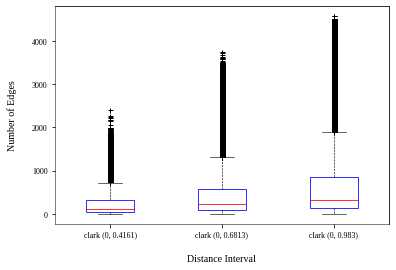

In [11]:
distance_function = 'clark'

# statistics
display(Markdown("<br>Statistics (*Clark*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
x_label = 'Distance Interval'
y_label = 'Number of Edges'
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (cl) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Number of Edges (*Clark*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Angular Separation**

<br>Statistics (*Angular Separation*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"angular_separation (0, 0.018)",19754,1.0,4.441328,1.995217,3.0,4.0,6.0,14.0,0.414644,3.433524
1,"angular_separation (0, 0.0654)",19754,1.0,2.082566,1.066140,1.0,2.0,3.0,6.0,0.504602,2.071481
2,"angular_separation (0, 0.1799)",19754,1.0,1.370558,0.526209,1.0,1.0,2.0,4.0,0.984197,2.871635


<br>*Graph Number of Edges (*Angular Separation*)*

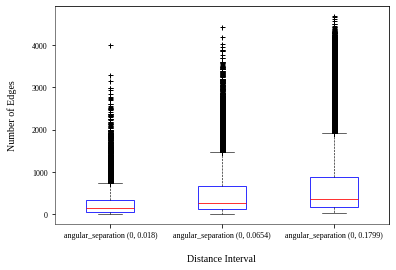

In [12]:
distance_function = 'angular_separation'

# statistics
display(Markdown("<br>Statistics (*Angular Separation*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
x_label = 'Distance Interval'
y_label = 'Number of Edges'
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (as) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Number of Edges (*Angular Separation*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Lance Williams**

<br>Statistics (*Lance Williams*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"lance_williams (0, 0.1789)",19754,1.0,4.489521,2.238210,3.0,5.0,6.0,12.0,-0.199679,2.075342
1,"lance_williams (0, 0.3041)",19754,1.0,2.221626,1.177630,1.0,2.0,3.0,6.0,0.322376,1.806147
2,"lance_williams (0, 0.466)",19754,1.0,1.450997,0.570147,1.0,1.0,2.0,4.0,0.820920,2.673500


<br>*Graph Number of Edges (*Lance Williams*)*

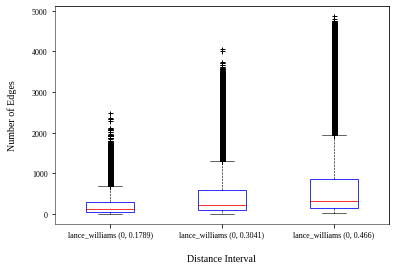

In [13]:
distance_function = 'lance_williams'

# statistics
display(Markdown("<br>Statistics (*Lance Williams*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
x_label = 'Distance Interval'
y_label = 'Number of Edges'
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (lw) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Number of Edges (*Lance Williams*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Soergel**

<br>Statistics (*Soergel*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"soergel (0, 0.3035)",19754,1.0,4.489673,2.238369,3.0,5.0,6.0,12.0,-0.199550,2.075415
1,"soergel (0, 0.4664)",19754,1.0,2.221575,1.177575,1.0,2.0,3.0,6.0,0.322390,1.806286
2,"soergel (0, 0.6357)",19754,1.0,1.451048,0.570240,1.0,1.0,2.0,4.0,0.821221,2.674175


<br>*Graph Number of Edges (*Soergel*)*

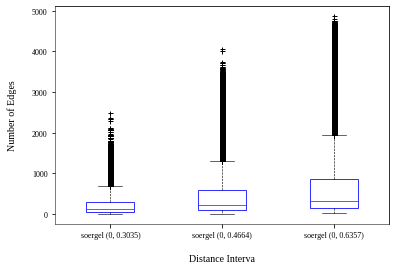

In [14]:
distance_function = 'soergel'

# statistics
display(Markdown("<br>Statistics (*Soergel*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
x_label = 'Distance Interva'
y_label = 'Number of Edges'
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (so) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Number of Edges (*Soergel*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

### **Analysis of Graph Number of Edges vs Sequence Length Relationship (*per Distance Function*)**

#### **Euclidean**

<br>*Graph Number of Edges vs Sequence Length (*Euclidean*)*

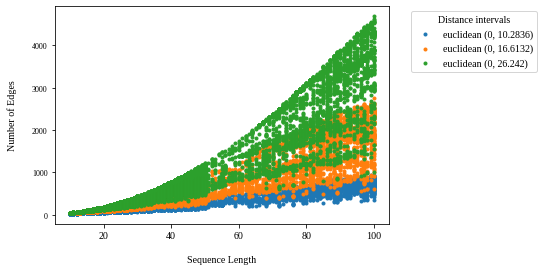

<br>*Graph Number of Edges vs Sequence Length - *euclidean (0, 10.2836)**

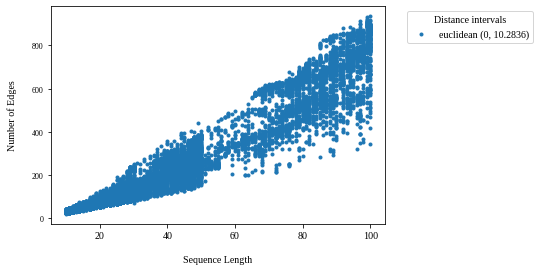

<br>*Graph Number of Edges vs Sequence Length - *euclidean (0, 16.6132)**

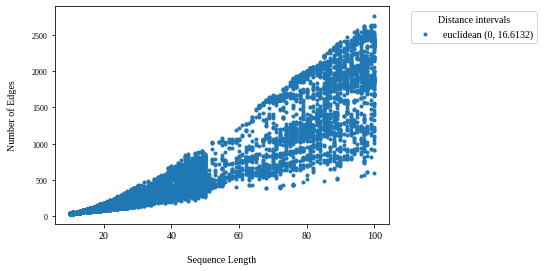

<br>*Graph Number of Edges vs Sequence Length - *euclidean (0, 26.242)**

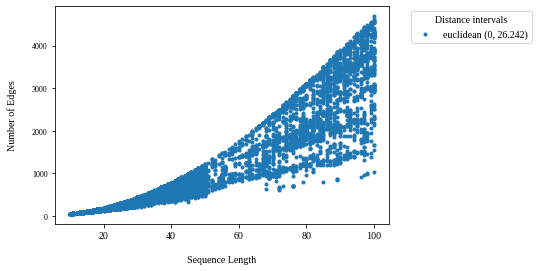

In [15]:
distance_function = 'euclidean'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='number_of_edges',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Number of Edges'
x_label = 'Sequence Length'
y_label = 'Number of Edges'
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Number of Edges vs Sequence Length (*Euclidean*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (eu) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# euclidean (0, 10.2836)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *euclidean (0, 10.2836)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (eu_0_10.2836) -scatter")
columns = ['euclidean (0, 10.2836)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# euclidean (0, 16.6132)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *euclidean (0, 16.6132)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (eu_0_16.6132) -scatter")
columns = ['euclidean (0, 16.6132)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# euclidean (0, 26.242)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *euclidean (0, 26.242)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (eu_0_26.242) -scatter")
columns = ['euclidean (0, 26.242)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Bhattacharyya**

<br>*Graph Number of Edges vs Sequence Length (*Bhattacharyya*)*

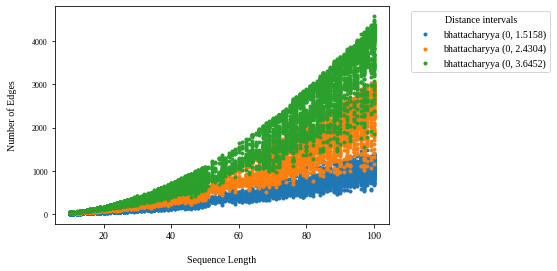

<br>*Graph Number of Edges vs Sequence Length - *Bhattacharyya (0, 1.5158)**

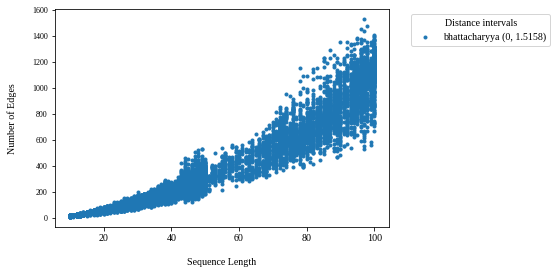

<br>*Graph Number of Edges vs Sequence Length - *Bhattacharyya (0, 2.4304)**

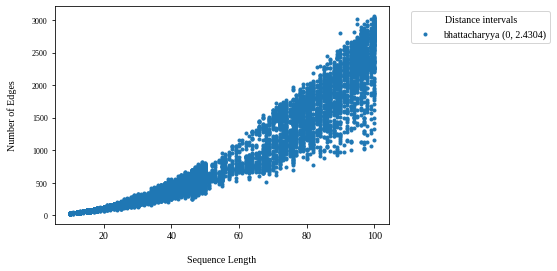

<br>*Graph Number of Edges vs Sequence Length - *Bhattacharyya (0, 3.6452)**

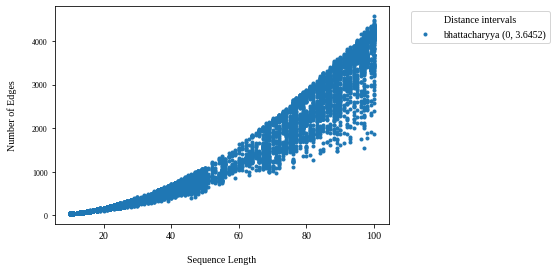

In [16]:
distance_function = 'bhattacharyya'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='number_of_edges',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Number of Edges'
x_label = 'Sequence Length'
y_label = 'Number of Edges'
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Number of Edges vs Sequence Length (*Bhattacharyya*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (ba) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# bhattacharyya (0, 1.5158)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Bhattacharyya (0, 1.5158)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (ba_0_1.5158) -scatter")
columns = ['bhattacharyya (0, 1.5158)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# bhattacharyya (0, 2.4304)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Bhattacharyya (0, 2.4304)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (ba_0_2.4304) -scatter")
columns = ['bhattacharyya (0, 2.4304)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# bhattacharyya (0, 3.6452)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Bhattacharyya (0, 3.6452)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (ba_0_3.6452) -scatter")
columns = ['bhattacharyya (0, 3.6452)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Canberra**

<br>*Graph Number of Edges vs Sequence Length (*Canberra*)*

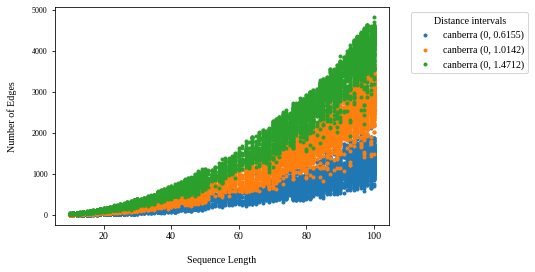

<br>*Graph Number of Edges vs Sequence Length - *Canberra (0, 0.6155)**

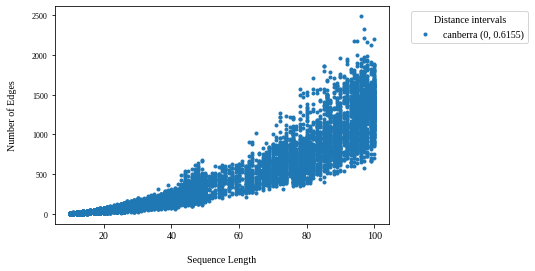

<br>*Graph Number of Edges vs Sequence Length - *Canberra (0, 1.0142)**

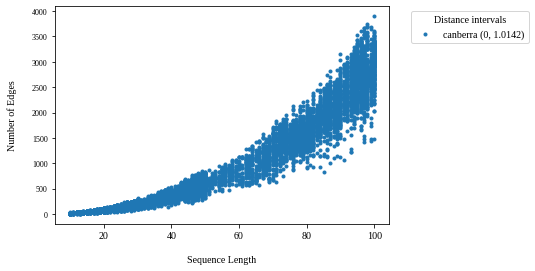

<br>*Graph Number of Edges vs Sequence Length - *Canberra (0, 1.4712)**

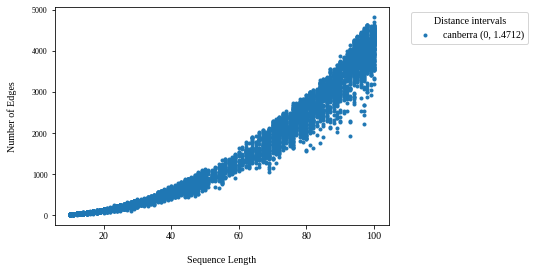

In [17]:
distance_function = 'canberra'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='number_of_edges',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Number of Edges'
x_label = 'Sequence Length'
y_label = 'Number of Edges'
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Number of Edges vs Sequence Length (*Canberra*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (ca) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# canberra (0, 0.6155)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Canberra (0, 0.6155)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (ca_0_0.6155) -scatter")
columns = ['canberra (0, 0.6155)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# canberra (0, 1.0142)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Canberra (0, 1.0142)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (ca_0_1.0142) -scatter")
columns = ['canberra (0, 1.0142)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# canberra (0, 1.4712)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Canberra (0, 1.4712)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (ca_0_1.4712) -scatter")
columns = ['canberra (0, 1.4712)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Clark**

<br>*Graph Number of Edges vs Sequence Length (*Clark*)*

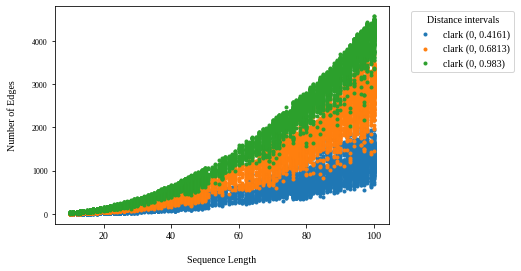

<br>*Graph Number of Edges vs Sequence Length - *Clark (0, 0.4161)**

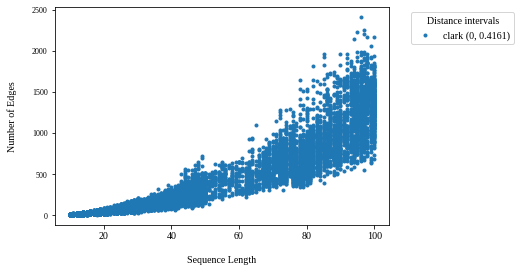

<br>*Graph Number of Edges vs Sequence Length - *Clark (0, 0.6813)**

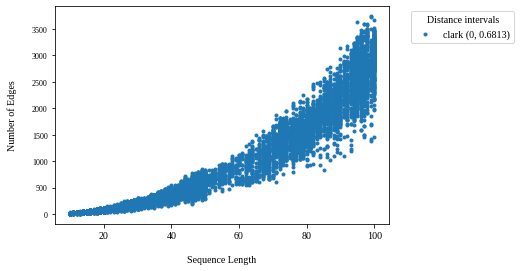

<br>*Graph Number of Edges vs Sequence Length - *Clark (0, 0.983)**

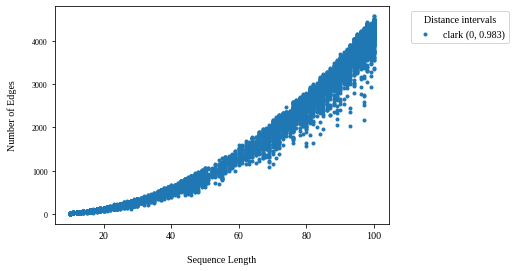

In [18]:
distance_function = 'clark'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='number_of_edges',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Number of Edges'
x_label = 'Sequence Length'
y_label = 'Number of Edges'
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Number of Edges vs Sequence Length (*Clark*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (cl) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# clark (0, 1.5158)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Clark (0, 0.4161)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (cl_0_0.4161) -scatter")
columns = ['clark (0, 0.4161)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# clark (0, 0.6813)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Clark (0, 0.6813)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (cl_0_0.6813) -scatter")
columns = ['clark (0, 0.6813)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# clark (0, 0.983)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Clark (0, 0.983)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (cl_0_0.983) -scatter")
columns = ['clark (0, 0.983)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Angular Separation**

<br>*Graph Number of Edges vs Sequence Length (*Angular Separation*)*

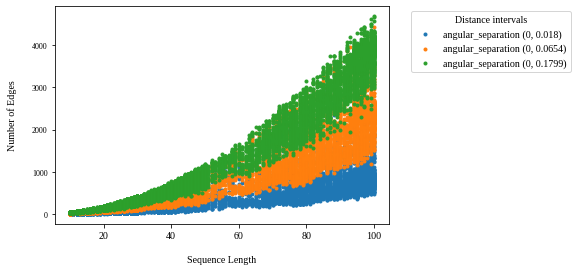

<br>*Graph Number of Edges vs Sequence Length - *Angular Separation (0, 0.018)**

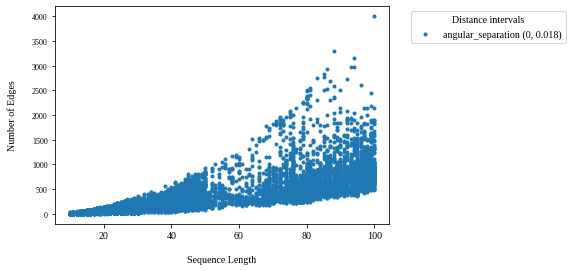

<br>*Graph Number of Edges vs Sequence Length - *Angular Separation (0, 0.0654)**

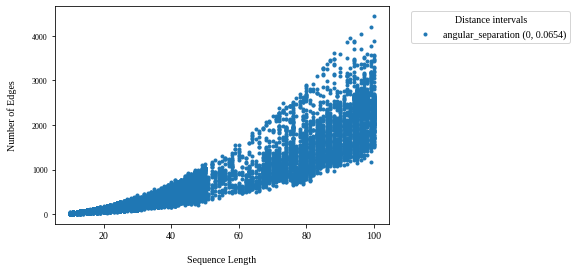

<br>*Graph Number of Edges vs Sequence Length - *Angular Separation (0, 0.1799)**

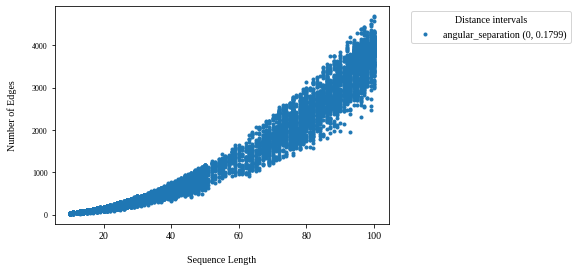

In [19]:
distance_function = 'angular_separation'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='number_of_edges',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Number of Edges'
x_label = 'Sequence Length'
y_label = 'Number of Edges'
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Number of Edges vs Sequence Length (*Angular Separation*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (as) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# angular_separation (0, 0.018)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Angular Separation (0, 0.018)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (as_0_0.018) -scatter")
columns = ['angular_separation (0, 0.018)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# angular_separation (0, 0.0654)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Angular Separation (0, 0.0654)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (as_0_0.0654) -scatter")
columns = ['angular_separation (0, 0.0654)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# angular_separation (0, 0.1799)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Angular Separation (0, 0.1799)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (as_0_0.1799) -scatter")
columns = ['angular_separation (0, 0.1799)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Lance Williams**

<br>*Graph Number of Edges vs Sequence Length (*Lance Williams*)*

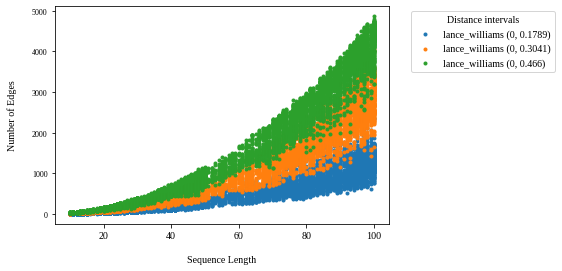

<br>*Graph Number of Edges vs Sequence Length - *Lance Williams (0, 0.1789)**

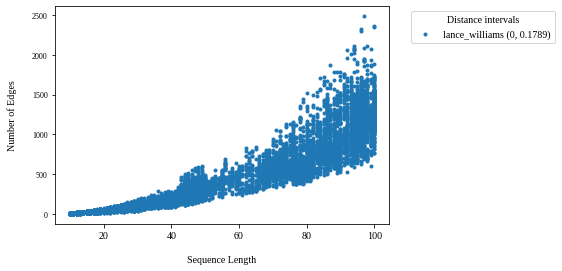

<br>*Graph Number of Edges vs Sequence Length - *Lance Williams (0, 0.3041)**

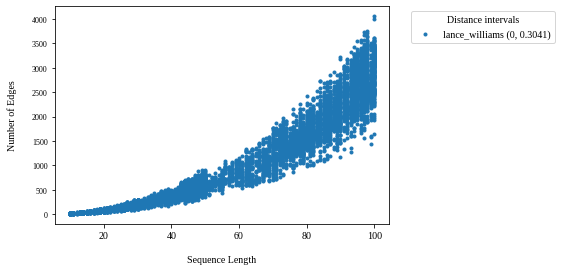

<br>*Graph Number of Edges vs Sequence Length - *Lance Williams (0, 0.466)**

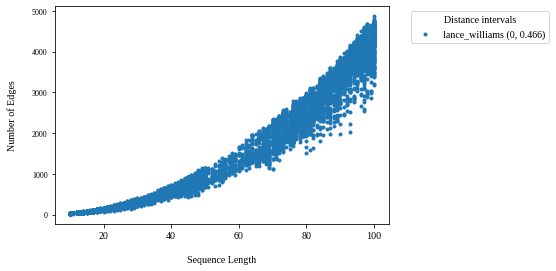

In [20]:
distance_function = 'lance_williams'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='number_of_edges',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Number of Edges'
x_label = 'Sequence Length'
y_label = 'Number of Edges'
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Number of Edges vs Sequence Length (*Lance Williams*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (lw) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# lance_williams (0, 0.1789)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Lance Williams (0, 0.1789)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (lw_0_0.1789) -scatter")
columns = ['lance_williams (0, 0.1789)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# lance_williams (0, 0.3041)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Lance Williams (0, 0.3041)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (lw_0_0.3041) -scatter")
columns = ['lance_williams (0, 0.3041)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# lance_williams (0, 0.466)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Lance Williams (0, 0.466)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (lw_0_0.466) -scatter")
columns = ['lance_williams (0, 0.466)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Soergel**

<br>*Graph Number of Edges vs Sequence Length (*Soergel*)*

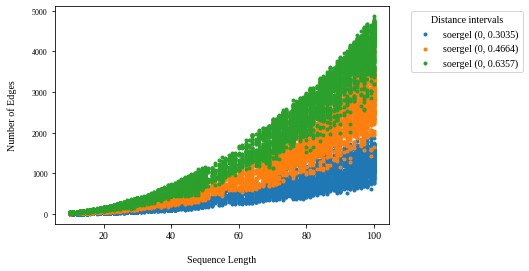

<br>*Graph Number of Edges vs Sequence Length - *Soergel (0, 0.3035)**

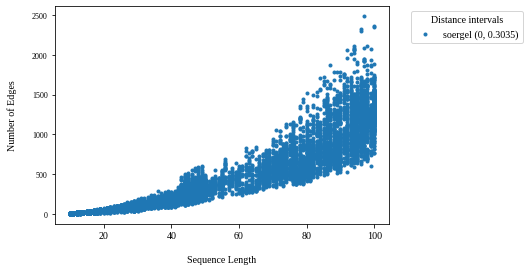

<br>*Graph Number of Edges vs Sequence Length - *Soergel (0, 0.4664)**

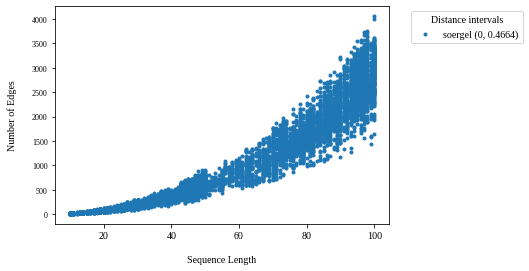

<br>*Graph Number of Edges vs Sequence Length - *Soergel (0, 0.6357)**

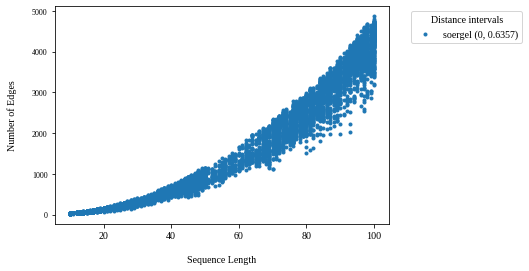

In [21]:
distance_function = 'soergel'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='number_of_edges',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Number of Edges'
x_label = 'Sequence Length'
y_label = 'Number of Edges'
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Number of Edges vs Sequence Length (*Soergel*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (so) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# soergel (0, 0.3035)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Soergel (0, 0.3035)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (so_0_0.3035) -scatter")
columns = ['soergel (0, 0.3035)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# soergel (0, 0.4664)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Soergel (0, 0.4664)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (so_0_0.4664) -scatter")
columns = ['soergel (0, 0.4664)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# soergel (0, 0.6357)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Soergel (0, 0.6357)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (so_0_0.6357) -scatter")
columns = ['soergel (0, 0.6357)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()